In [16]:
from langchain_core.tools import tool
import httpx
from geopy.geocoders import Nominatim
import json

def get_coordinates(city_name: str) -> tuple[float, float]:
    """도시 이름을 받아 위도와 경도를 반환합니다."""
    geolocator = Nominatim(user_agent="weather_app_langgraph")
    location = geolocator.geocode(city_name)
    if location:
        return location.latitude, location.longitude
    raise ValueError(f"좌표를 찾을 수 없습니다: {city_name}")

@tool
def get_weather(city_name: str) -> str:
    """도시 이름을 받아 해당 도시의 현재 날씨 정보를 반환합니다."""
    print(f"날씨 조회: {city_name}")
    latitude, longitude = get_coordinates(city_name)
    url = f"https://api.open-meteo.com/v1/forecast?latitude={latitude}&longitude={longitude}&current_weather=true&timezone=Asia/Seoul"
    response = httpx.get(url)
    response.raise_for_status()
    return json.dumps(response.json())

tools = [get_weather]

In [17]:
tools[0].invoke({"city_name": "부산"})

날씨 조회: 부산


'{"latitude": 35.2, "longitude": 129.0625, "generationtime_ms": 0.057697296142578125, "utc_offset_seconds": 32400, "timezone": "Asia/Seoul", "timezone_abbreviation": "GMT+9", "elevation": 26.0, "current_weather_units": {"time": "iso8601", "interval": "seconds", "temperature": "\\u00b0C", "windspeed": "km/h", "winddirection": "\\u00b0", "is_day": "", "weathercode": "wmo code"}, "current_weather": {"time": "2025-12-14T17:15", "interval": 900, "temperature": 4.2, "windspeed": 9.9, "winddirection": 303, "is_day": 0, "weathercode": 0}}'

In [18]:
from langgraph.prebuilt import ToolNode # 에이전트와 도구 간의 인터페이스 역할을 하며, 언어 모델의 지시에 따라 실제 도구 실행을 담당하는 핵심적인 중간 다리
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_google_genai import ChatGoogleGenerativeAI

from dotenv import load_dotenv
load_dotenv()

# * 기상 전문가 서브 그래프 생성
def create_weather_agent():
    """날씨 관련 질문을 처리하는 전문가 서브그래프를 생성합니다."""
    model = ChatGoogleGenerativeAI(model="gemini-2.5-flash").bind_tools(tools)
    tool_node = ToolNode([get_weather])

    def call_model(state: MessagesState):
        return {"messages": [model.invoke(state["messages"])]}

    graph_builder = StateGraph(MessagesState)
    graph_builder.add_node("call_model", call_model)
    graph_builder.add_node("tool_node", tool_node)

    graph_builder.add_edge(START, "call_model")
    graph_builder.add_conditional_edges(
        "call_model",
        lambda s: "tool_node" if s["messages"][-1].tool_calls else END,
        {"tool_node": "tool_node", END: END},
    )
    graph_builder.add_edge("tool_node", "call_model")
    return graph_builder.compile()

In [19]:
from typing import Literal

# * 라우터 생성
def router(state: MessagesState) -> Literal["weather_expert", "general_agent"]:
    query = state["messages"][-1].content.lower()
    if "날씨" in query or "기온" in query:
        print("라우팅 결정: 기상 전문가에게 위임")
        return "weather_expert"
    print("라우팅 결정: 일반 에이전트가 처리")
    return "general_agent"

In [20]:
# * 메인 그래프 생성
def create_main_agent(weather_subgraph):
    """질문을 라우팅하고 처리하는 메인 에이전트 그래프를 생성합니다."""
    main_model = ChatGoogleGenerativeAI(model="gemini-2.5-flash") # 모델을 다르게 사용 가능

    graph_builder = StateGraph(MessagesState)
    graph_builder.add_node(
        "general_agent", lambda s: {"messages": [main_model.invoke(s["messages"])]}
    )
    graph_builder.add_node("weather_expert", weather_subgraph)
    graph_builder.add_conditional_edges(
        START,
        router,
        {
            "weather_expert": "weather_expert",
            "general_agent": "general_agent",
        },
    )
    graph_builder.add_edge("general_agent", END)
    graph_builder.add_edge("weather_expert", END)
    return graph_builder.compile()

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


=== LangGraph 서브그래프 예제 (기상 전문가) ===



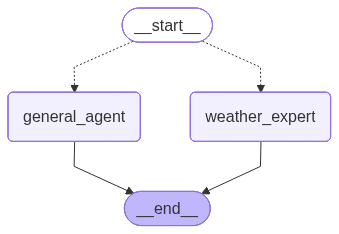

In [21]:
from IPython.display import Image, display

print("=== LangGraph 서브그래프 예제 (기상 전문가) ===\n")
weather_agent = create_weather_agent()
main_agent = create_main_agent(weather_agent)

# 그래프 이미지 로컬에 저장
# main_graph_image = main_agent.get_graph(xray=True).draw_mermaid_png()
# with open("main_agent_graph.png", "wb") as f:
#     f.write(main_graph_image)

try:
    display(Image(main_agent.get_graph().draw_mermaid_png()))
except Exception:
    pass

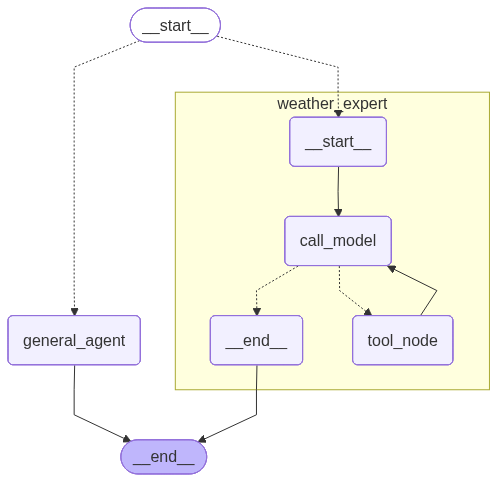

In [22]:
try:
    display(Image(main_agent.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    pass

In [23]:
from langchain_core.messages import HumanMessage

query = "부산 날씨 어때?"
result = main_agent.invoke({"messages": [HumanMessage(content=query)]})

result

라우팅 결정: 기상 전문가에게 위임
날씨 조회: 부산


{'messages': [HumanMessage(content='부산 날씨 어때?', additional_kwargs={}, response_metadata={}, id='04e44e27-bb82-432d-9a5f-1add7e774a21'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"city_name": "\\ubd80\\uc0b0"}'}, '__gemini_function_call_thought_signatures__': {'ac9e4ed1-9684-4272-b7db-4dab1b141ad5': 'CvABAXLI2nxkpwmmKJyyW8huxonIbLnFqE1bNNCQYbcNQUQVwSg33O+C6wSYwN7/NdeTMsE9w09sR7dtdMoPPeAhrdY9HrrWMV8YV2vQEcn1kR7J8CYKwFmFjJBGmIimyzP5ZyOGFbpERcuqQdIpNUdp/OpeTW83HrK1LLLbc3cgCnLm2DKjwCG3/HI5oZvy3uepahuHcLfblaruDhG651narOkUjPBXdBKSLseV6Js9eMNo4KfIFZ8+icW8qdmziIWxfHfXw1yWekwDcJE60wZaDph10Fq+cRW9nyh60DuVjAI9nxYal1j6zGgbJadJd/Ys'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019b1bf8-d4d5-76e1-871d-1b2e304c4bae-0', tool_calls=[{'name': 'get_weather', 'args': {'city_name': '부산'}, 'id': 'ac9e4ed1-9684-4272-b7db-4dab1b141ad5', 'type': 'tool_

In [24]:
from langchain_core.messages import HumanMessage

query = "랭그래프에 대해 핵심만 간단히 설명해줘."
result = main_agent.invoke({"messages": [HumanMessage(content=query)]})

result

라우팅 결정: 일반 에이전트가 처리


{'messages': [HumanMessage(content='랭그래프에 대해 핵심만 간단히 설명해줘.', additional_kwargs={}, response_metadata={}, id='7065bf0e-8766-463f-954a-5622e3512de6'),
  AIMessage(content='랭그래프(LangGraph)는 랭체인(LangChain) 위에 구축된 프레임워크로, **복잡하고 반복적인 AI 에이전트 시스템**을 만들기 위해 사용됩니다.\n\n핵심은 다음과 같습니다:\n\n1.  **그래프 구조:** 에이전트의 작동 흐름(워크플로우)을 **\'노드(단계)\'와 \'엣지(전환)\'**로 이루어진 그래프 형태로 정의합니다. 각 노드는 LLM 호출, 도구 사용, 조건부 판단 등 특정 액션을 수행합니다.\n2.  **상태 관리:** 에이전트가 이전 단계의 결과나 정보를 기억하고 활용할 수 있도록 **\'상태(state)\'**를 관리합니다.\n3.  **반복 (사이클):** 가장 중요한 특징으로, 에이전트가 필요에 따라 여러 단계를 **반복(루프)하며 스스로 생각하고, 행동하고, 결과를 평가하고, 다시 행동하는** 과정을 수행할 수 있게 합니다.\n\n간단히 말해, LangGraph는 AI 에이전트가 **"생각 -> 행동 -> 평가 -> 다시 생각"**과 같은 복잡하고 반복적인 의사결정 과정을 **"기억(상태)"**하며 **"흐름(그래프)"**에 따라 유연하게 수행하도록 돕는 도구입니다.', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019b1bf9-6f82-7f73-bd6c-a5ce4681d7c8-0', usage_metadata={'input_tokens': 14, 'output_token